In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/bank_churn.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [5]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df["Exited"].value_counts(normalize=True) * 100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

In [9]:
churn_rate = df["Exited"].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 20.37%


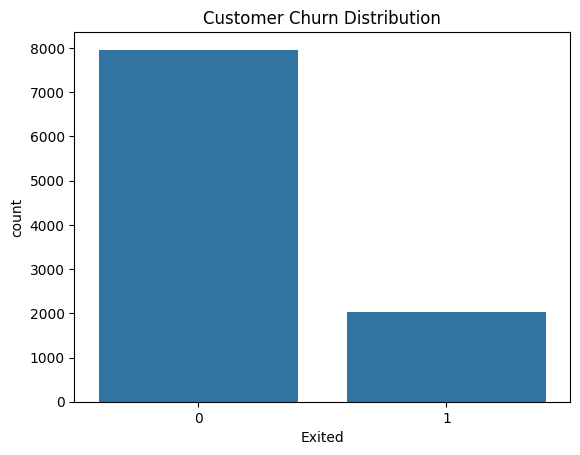

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [11]:
df_clean = df.drop(["CustomerId", "Surname", "Year"], axis=1)

In [14]:
df_clean.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df_clean.to_csv("../data/bank_churn_clean.csv", index=False)

In [15]:
geo_churn = pd.crosstab(df["Geography"], df["Exited"])
geo_churn

Exited,0,1
Geography,,
France,4204,810
Germany,1695,814
Spain,2064,413


In [16]:
geo_churn_pct = pd.crosstab(
    df["Geography"],
    df["Exited"],
    normalize="index"
) * 100

geo_churn_pct

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


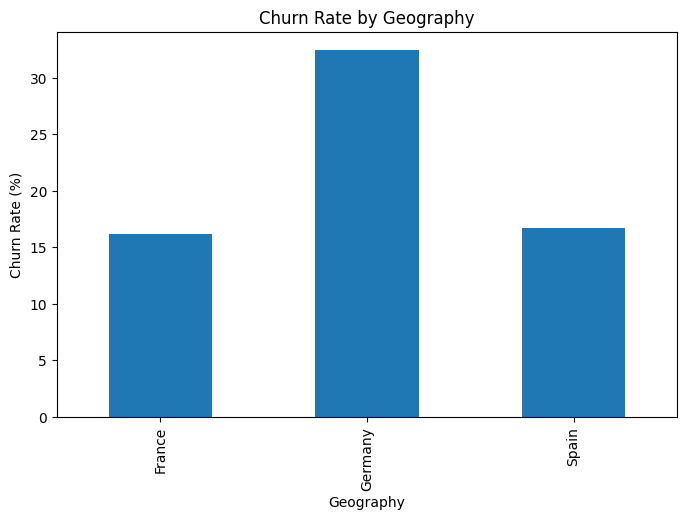

In [17]:
geo_churn_pct[1].plot(
    kind="bar",
    figsize=(8,5),
    title="Churn Rate by Geography"
)

plt.ylabel("Churn Rate (%)")
plt.show()

In [18]:
df.groupby("Exited")["Age"].mean()

Exited
0    37.408389
1    44.837997
Name: Age, dtype: float64

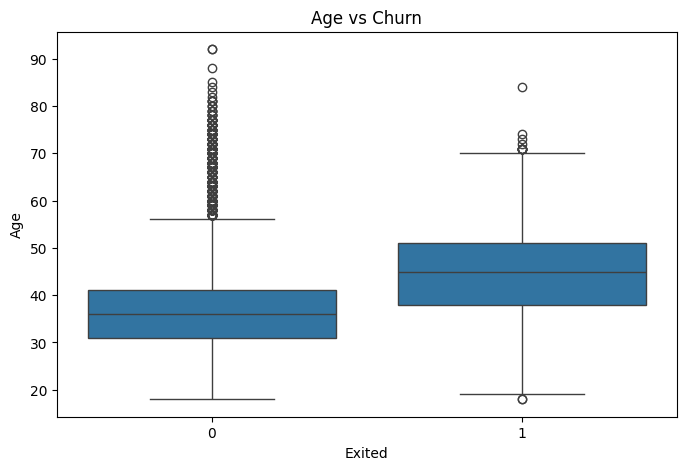

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Exited", y="Age", data=df)
plt.title("Age vs Churn")
plt.show()

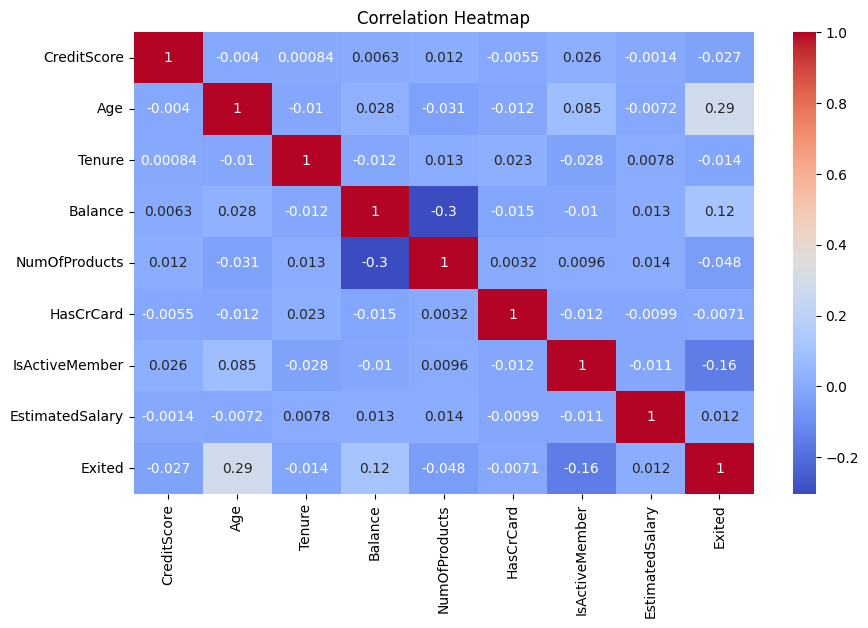

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_clean.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [22]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 30, 45, 60, 100],
    labels=["<30", "30-45", "46-60", "60+"]
)

df[["Age", "AgeGroup"]].head()

,Age,AgeGroup
0,42,30-45
1,41,30-45
2,42,30-45
3,39,30-45
4,43,30-45


In [23]:
df["CreditBand"] = pd.cut(
    df["CreditScore"],
    bins=[0, 500, 700, 1000],
    labels=["Low", "Medium", "High"]
)

df[["CreditScore", "CreditBand"]].head()

,CreditScore,CreditBand
0,619,Medium
1,608,Medium
2,502,Medium
3,699,Medium
4,850,High


In [24]:
df["TenureGroup"] = pd.cut(
    df["Tenure"],
    bins=[-1, 3, 7, 10],
    labels=["New", "Mid-Term", "Long-Term"]
)

df[["Tenure", "TenureGroup"]].head()

,Tenure,TenureGroup
0,2,New
1,1,New
2,8,Long-Term
3,1,New
4,2,New


In [25]:
df["BalanceSegment"] = pd.cut(
    df["Balance"],
    bins=[-1, 0, 100000, df["Balance"].max()],
    labels=["Zero Balance", "Low Balance", "High Balance"]
)

df[["Balance", "BalanceSegment"]].head()

,Balance,BalanceSegment
0,0.00,Zero Balance
1,83807.86,Low Balance
2,159660.80,High Balance
3,0.00,Zero Balance
4,125510.82,High Balance


In [26]:
age_churn = pd.crosstab(
    df["AgeGroup"],
    df["Exited"],
    normalize="index"
) * 100

age_churn

Exited,0,1
AgeGroup,,
<30,92.479675,7.520325
30-45,84.259416,15.740584
46-60,48.876746,51.123254
60+,75.215517,24.784483


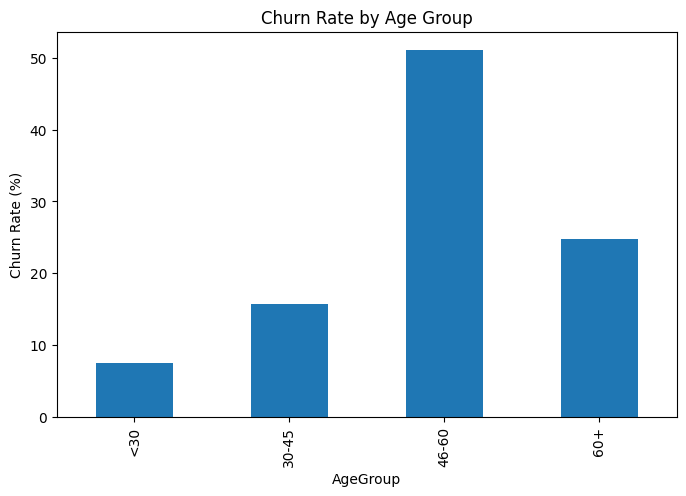

In [27]:
age_churn[1].plot(
    kind="bar",
    figsize=(8,5),
    title="Churn Rate by Age Group"
)

plt.ylabel("Churn Rate (%)")
plt.show()

In [28]:
credit_churn = pd.crosstab(
    df["CreditBand"],
    df["Exited"],
    normalize="index"
) * 100

credit_churn

Exited,0,1
CreditBand,,
Low,76.360809,23.639191
Medium,79.714789,20.285211
High,80.134788,19.865212


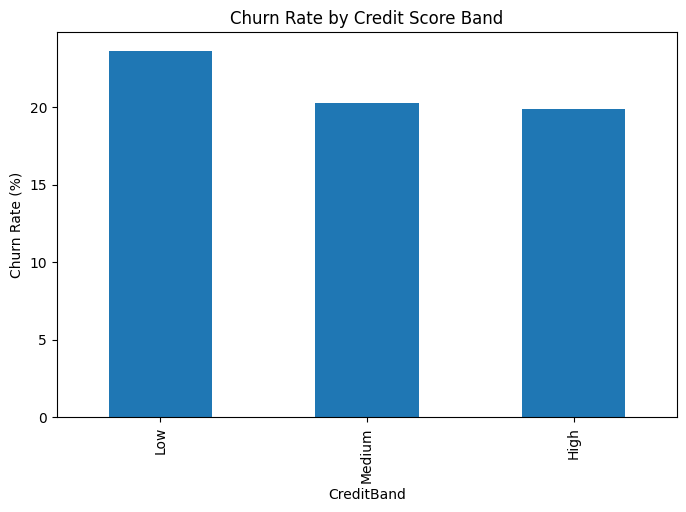

In [29]:
credit_churn[1].plot(
    kind="bar",
    figsize=(8,5),
    title="Churn Rate by Credit Score Band"
)

plt.ylabel("Churn Rate (%)")
plt.show()

In [30]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Exited"],
    normalize="index"
) * 100

tenure_churn

Exited,0,1
TenureGroup,,
New,78.858773,21.141227
Mid-Term,80.355355,19.644645
Long-Term,79.551821,20.448179


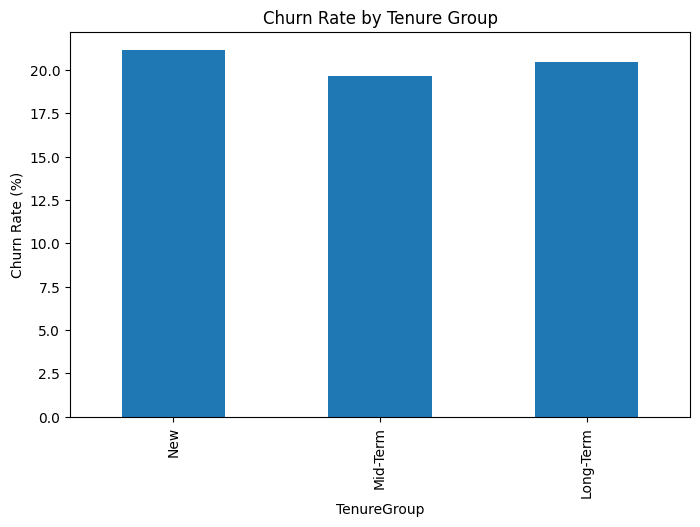

In [31]:
tenure_churn[1].plot(
    kind="bar",
    figsize=(8,5),
    title="Churn Rate by Tenure Group"
)

plt.ylabel("Churn Rate (%)")
plt.show()

In [32]:
balance_churn = pd.crosstab(
    df["BalanceSegment"],
    df["Exited"],
    normalize="index"
) * 100

balance_churn

Exited,0,1
BalanceSegment,,
Zero Balance,86.176389,13.823611
Low Balance,79.419192,20.580808
High Balance,74.765576,25.234424


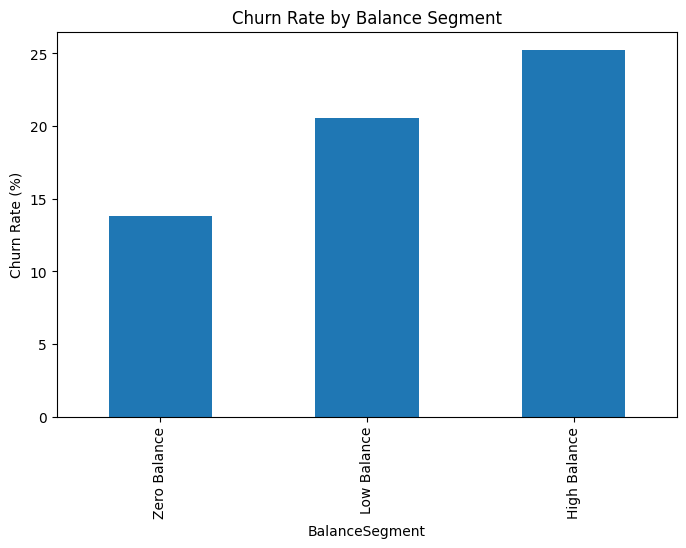

In [33]:
balance_churn[1].plot(
    kind="bar",
    figsize=(8,5),
    title="Churn Rate by Balance Segment"
)

plt.ylabel("Churn Rate (%)")
plt.show()

In [34]:
high_value = df[df["Balance"] > 100000]

high_value_churn = high_value["Exited"].mean() * 100

print(f"High Value Customer Churn Rate: {high_value_churn:.2f}%")

High Value Customer Churn Rate: 25.23%


In [35]:
revenue_risk = df[df["Exited"] == 1]["Balance"].sum()

print(f"Revenue at Risk: €{revenue_risk:,.2f}")

Revenue at Risk: €185,588,094.63


In [36]:
total_customers = len(df)

print("Total Customers:", total_customers)

Total Customers: 10000


In [37]:
churned_customers = df["Exited"].sum()

print("Churned Customers:", churned_customers)

Churned Customers: 2037


In [38]:
retained_customers = len(df) - churned_customers

print("Retained Customers:", retained_customers)

Retained Customers: 7963


In [39]:
overall_churn_rate = df["Exited"].mean() * 100

print(f"Overall Churn Rate: {overall_churn_rate:.2f}%")

Overall Churn Rate: 20.37%


In [40]:
active_customers = df["IsActiveMember"].sum()

print("Active Customers:", active_customers)

Active Customers: 5151


In [41]:
avg_balance = df["Balance"].mean()

print(f"Average Balance: €{avg_balance:,.2f}")

Average Balance: €76,485.89


In [42]:
avg_credit_score = df["CreditScore"].mean()

print(f"Average Credit Score: {avg_credit_score:.2f}")

Average Credit Score: 650.53


In [43]:
revenue_risk = df[df["Exited"] == 1]["Balance"].sum()

print(f"Revenue at Risk: €{revenue_risk:,.2f}")

Revenue at Risk: €185,588,094.63


In [44]:
kpi_summary = {
    "Total Customers": total_customers,
    "Churned Customers": churned_customers,
    "Retained Customers": retained_customers,
    "Overall Churn Rate": round(overall_churn_rate, 2),
    "Active Customers": active_customers,
    "Average Balance": round(avg_balance, 2),
    "Average Credit Score": round(avg_credit_score, 2),
    "Revenue At Risk": round(revenue_risk, 2)
}

kpi_summary

{'Total Customers': 10000,
 'Churned Customers': np.int64(2037),
 'Retained Customers': np.int64(7963),
 'Overall Churn Rate': np.float64(20.37),
 'Active Customers': np.int64(5151),
 'Average Balance': np.float64(76485.89),
 'Average Credit Score': np.float64(650.53),
 'Revenue At Risk': np.float64(185588094.63)}

In [45]:
df.to_csv("../data/bank_churn_processed.csv", index=False)

# Customer Segmentation using K-Means

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [47]:
segmentation_features = df[
    [
        "CreditScore",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "EstimatedSalary"
    ]
]

In [48]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(segmentation_features)

In [49]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["CustomerSegment"] = kmeans.fit_predict(scaled_data)

In [50]:
df["CustomerSegment"].value_counts()

CustomerSegment
2    3084
3    2853
1    2673
0    1390
Name: count, dtype: int64

In [51]:
segment_churn = pd.crosstab(
    df["CustomerSegment"],
    df["Exited"],
    normalize="index"
) * 100

segment_churn

Exited,0,1
CustomerSegment,,
0,54.964029,45.035971
1,80.733259,19.266741
2,87.937743,12.062257
3,81.633368,18.366632


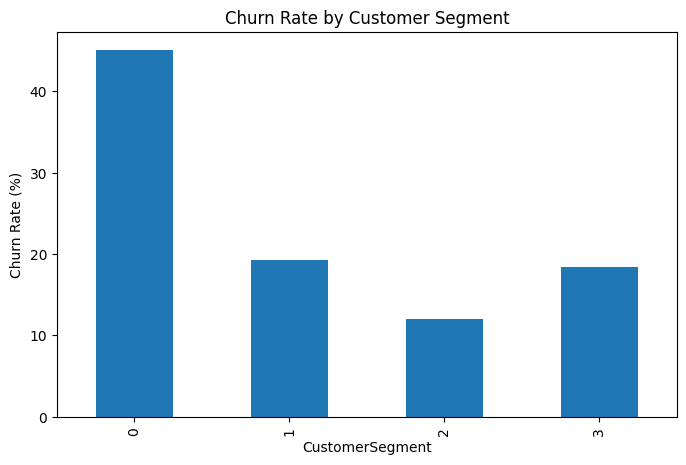

In [52]:
segment_churn[1].plot(
    kind="bar",
    figsize=(8,5),
    title="Churn Rate by Customer Segment"
)

plt.ylabel("Churn Rate (%)")
plt.show()

In [53]:
segment_profile = df.groupby("CustomerSegment")[
    [
        "Age",
        "Balance",
        "EstimatedSalary",
        "CreditScore"
    ]
].mean()

segment_profile

,Age,Balance,EstimatedSalary,CreditScore
CustomerSegment,,,,
0,58.005036,78417.186245,95406.827432,644.377698
1,36.084549,111720.838253,102528.292308,644.879910
2,35.858301,10867.335574,99601.975383,650.248054
3,35.594111,113464.542741,100615.594553,659.121626


In [55]:
df = pd.read_csv("data/bank_churn_segmented.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'data/bank_churn_segmented.csv'

In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Features for segmentation
segmentation_features = df[
    [
        "CreditScore",
        "Age",
        "Tenure",
        "Balance",
        "NumOfProducts",
        "EstimatedSalary"
    ]
]

# Scale data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_features)

# KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["CustomerSegment"] = kmeans.fit_predict(scaled_data)

# Check results
df["CustomerSegment"].value_counts()

CustomerSegment
2    3084
3    2853
1    2673
0    1390
Name: count, dtype: int64

In [57]:
df.to_csv("../data/bank_churn_segmented.csv", index=False)

In [59]:
df.columns.tolist()

['Year',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'AgeGroup',
 'CreditBand',
 'TenureGroup',
 'BalanceSegment',
 'CustomerSegment']